# 07 — Main results, UU flow (the third experiment)

The first two experiments ran arbitrage-only flow, where every trade is a net
loss to the LP by construction: net-vs-HODL then improves monotonically as
volume is suppressed, and the ranking follows trade count rather than skill.
This one adds a deterministic uninformed-user flow, so raising the fee costs
retained retail revenue and a policy has to _discriminate_ to win.

**Needs:** `results-uu/matrix/` from `uv run python run_matrix.py --uu`. The
notebook reads the per-cell metrics directly when `results-uu/summary.csv` is
not there yet, so it runs against a partial matrix as well as a finished one.

**Pre-registration:** `docs/superpowers/specs/2026-08-09-uu-matrix-preregistration.md`,
recorded before this matrix ran. It fixes the family, the test, the baseline
(`MyHook@3000`) and — new here — declares **two co-primary valuations** of the
same quantity, both always reported side by side:

| column          | leftover inventory marked at |
| --------------- | ---------------------------- |
| `net_result`    | end-of-window prices         |
| `net_result_tt` | trade-time prices            |

The second was chosen _after_ inspecting arb-only results (the 2026-08-09 audit
found the end-of-window valuation carries an inventory-revaluation term that
flipped four conclusions). It is declared before any UU data existed, but its
motivation is post-hoc with respect to the first experiment and the paper must
say so. **Where the two disagree, the disagreement is the finding — it is not
resolved by taking the friendlier number.**

**Claim boundary.** This is a controlled comparison under a _synthetic_ two-flow
model. The UU model's λ and κ are swept, not asserted; slippage and retail gas
are outside `r`; participation is applied as a deterministic volume share, not a
coin flip. Nothing here licenses "dynamic beats static" in general.


In [21]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from experiments.aggregate import (
    BASELINE_POLICY,
    by_regime,
    load_results,
    paired_against_baseline,
)
from experiments.figures import draw_all_uu
from experiments.stats import analyse

# Which operating point of the third experiment this run reports. Both are
# pre-registered and both are reported; neither replaces the other, so the
# figures and the analysis CSVs are named apart and never overwrite each other
# (2026-08-11-informed-share-preregistration.md).
#
#   UU_CONFIG=headline  uv run jupyter nbconvert --execute ...   (the default)
#   UU_CONFIG=informed  uv run jupyter nbconvert --execute ...
CONFIGS = {
    "headline": {
        "results": "results-uu",
        "prefix": "uu_",
        "label": "κ = 1.0 — calibrated turnover (post gas-fix rerun of 2026-08-12)",
    },
    "informed": {
        "results": "results-uu/turnover-0.1",
        "prefix": "uu_t01_",
        "label": "κ = 0.1 — informed-heavy operating point (post gas-fix rerun of 2026-08-12)",
    },
    "t003": {
        "results": "results-uu/turnover-0.03",
        "prefix": "uu_t003_",
        "label": "κ = 0.03 — arbitrage-dominated (post gas-fix run of 2026-08-12)",
    },
    "t03": {
        "results": "results-uu/turnover-0.3",
        "prefix": "uu_t03_",
        "label": "κ = 0.3 — intermediate (post gas-fix run of 2026-08-12)",
    },
    "t3": {
        "results": "results-uu/turnover-3",
        "prefix": "uu_t3_",
        "label": "κ = 3.0 — retail-flooded (post gas-fix run of 2026-08-12)",
    },
}
CONFIG = os.environ.get("UU_CONFIG", "headline")
assert CONFIG in CONFIGS, f"UU_CONFIG must be one of {sorted(CONFIGS)}"
settings = CONFIGS[CONFIG]

RESULTS = ROOT / settings["results"]
PREFIX = settings["prefix"]
LABEL = settings["label"]
print(f"operating point: {CONFIG} — {LABEL}")

FIGURES = ROOT / "paper" / "Image"
FIGURES.mkdir(parents=True, exist_ok=True)

# The per-swap JSONL traces, which only the fee figures need. They live beside
# the per-cell metrics; the original run wrote them to `results/` and they were
# moved back (2026-08-10, see PROGRESS.md). The glob is non-recursive, so the
# nested second operating point never contributes traces to the headline.
TRACES = RESULTS

# summary.csv is written only when the run reaches the end. The per-cell
# metrics are written as each cell completes, so reading those makes this
# notebook runnable against a matrix still in flight -- and identical once it
# lands, because summary.csv is built from exactly these files.
summary = RESULTS / "summary.csv"
if summary.exists():
    frame = pd.read_csv(summary)
    source = summary
else:
    frame = load_results(RESULTS / "matrix")
    source = RESULTS / "matrix"

# 9 policies x 3 pairs x 72 windows x 3 gas: the four hook policies of the
# paper (ABHook, BAHook, DAHook, MEVChargeHook), the four static baselines,
# and the recalibrated VolatilityHook (2026-08-12: coefficient rescaled to
# per-minute sigma, dt-normalised estimator, slimmed hot path). The three
# remaining dropped policies (MEVChargeHookFixed, PegCapture, PegDefence)
# exist only in the archived pre-fix matrix.
CELLS_EXPECTED = 5_832
print(f"{len(frame)} of {CELLS_EXPECTED} cells, read from {source.relative_to(ROOT)}")
if len(frame) < CELLS_EXPECTED:
    print("PARTIAL MATRIX -- every number below is provisional")
frame.head(3)


operating point: headline — κ = 1.0 — calibrated turnover (post gas-fix rerun of 2026-08-12)
5832 of 5832 cells, read from results-uu/summary.csv


,policy,hook,fee_pips,pair,window_start_ms,regime,volatility,gas_price_wei,address_mode,fee_income,...,gas_cost,retained_volume,uu_volume,arb_volume,uu_fee_share,uu_participation,trade_count,conservation_error_token0,conservation_error_token1,error
0,BAHook,BAHook,0,ETH/SHIB,1704067200000,low,0.031161,5000000000,persistent,5934.668651,...,874.160892,1.413755e+06,1.354795e+06,29955.962794,0.967933,0.305060,670,0.000000e+00,0.000000e+00,NaN
1,BAHook,BAHook,0,ETH/SHIB,1704067200000,low,0.031161,20000000000,persistent,3977.914604,...,1493.029692,9.785282e+05,9.308245e+05,27017.916422,0.988521,0.222297,290,0.000000e+00,0.000000e+00,NaN
2,BAHook,BAHook,0,ETH/SHIB,1704067200000,low,0.031161,80000000000,persistent,1844.880846,...,1982.882430,5.965498e+05,5.670589e+05,17614.185465,0.979512,0.147225,97,-1.196244e-16,-1.456982e-16,NaN


## Health checks first

Three of these are carried over: errors, conservation, and the zero-trade count.
Conservation is not a development aid — it caught a silent int64 overflow in a
pandas sum that would have corrupted every figure below without anything
failing.

The fourth is new and specific to this experiment. The UU model only does its
job if participation actually responds to price: if `uu_participation` were flat
across the static fee levels, the second blade of the scissors would not be
cutting and the arb-only degeneracy would be back under a new name.


In [22]:
failed = int(frame["error"].notna().sum()) if "error" in frame else 0
worst = (
    frame[["conservation_error_token0", "conservation_error_token1"]].abs().max().max()
)
print(f"errors: {failed}")
print(f"worst conservation error: {worst:.2e}")
assert failed == 0 and worst < 1e-6, "do not read anything below until this passes"

zero_trade = frame[frame["trade_count"] == 0]
print(f"zero-trade cells: {len(zero_trade)}")
if len(zero_trade):
    print(zero_trade.groupby("pair").size().to_string())

errors: 0
worst conservation error: 5.38e-16
zero-trade cells: 0


In [23]:
# The calibration check. P is a probability, so it must lie in (0, 1]; and it
# must fall as the static fee rises, because the fee enters r through gamma.
# Monotonicity is asserted rather than eyeballed: it is the single assumption
# the whole third experiment rests on.
statics = frame[frame["policy"].str.startswith("MyHook@")].copy()
statics["level_bps"] = statics["policy"].str.removeprefix("MyHook@").astype(int) / 100

calibration = statics.groupby("level_bps").agg(
    uu_participation=("uu_participation", "mean"),
    uu_share_of_volume=("uu_volume", "sum"),
    arb_volume=("arb_volume", "sum"),
    net_result=("net_result", "mean"),
    net_result_tt=("net_result_tt", "mean"),
)
calibration["uu_share_of_volume"] /= (
    calibration["uu_share_of_volume"] + calibration["arb_volume"]
)
calibration = calibration.drop(columns="arb_volume")

p = frame["uu_participation"].dropna()
assert ((p > 0) & (p <= 1)).all(), "participation is a probability"
assert calibration["uu_participation"].is_monotonic_decreasing, (
    "a higher fee must retain less retail flow, or the fee is not entering r"
)
calibration.round(4)

,uu_participation,uu_share_of_volume,net_result,net_result_tt
level_bps,,,,
5.0,0.4914,0.7187,1643.9139,2195.4556
30.0,0.3007,0.8713,11890.1400,12508.5322
60.0,0.1636,0.9392,11932.2888,12577.7961
100.0,0.0753,0.9558,7936.1413,8614.3190


### Is the degeneracy actually gone?

Under arbitrage-only flow `net_result` rose monotonically with the static fee
level — the highest fee "won" by pricing the arbitrageur out entirely. The
pre-registration predicts an **interior optimum** here instead. This is a
prediction recorded in advance, so it is reported whichever way it comes out.


In [24]:
def interior_optimum(series: pd.Series) -> bool:
    """True when the best static level is neither the cheapest nor the dearest."""
    best = series.idxmax()
    return best not in (series.index.min(), series.index.max())


for valuation in ("net_result", "net_result_tt"):
    curve = calibration[valuation]
    verdict = (
        "interior optimum" if interior_optimum(curve) else "MONOTONE -- degenerate"
    )
    print(f"{valuation:14s} best at {curve.idxmax():>5.0f} bps   {verdict}")
    print("    " + "  ".join(f"{lvl:.0f}bps={v:,.0f}" for lvl, v in curve.items()))

net_result     best at    60 bps   interior optimum
    5bps=1,644  30bps=11,890  60bps=11,932  100bps=7,936
net_result_tt  best at    60 bps   interior optimum
    5bps=2,195  30bps=12,509  60bps=12,578  100bps=8,614


## By regime, both valuations

`retained_volume` travels with every metric on purpose: without it the
degenerate "charge the maximum and nobody trades" outcome reads as a win. Under
UU flow the volume split matters too — a policy can keep volume by keeping
_arbitrage_ volume, which is the opposite of the thing worth keeping.


In [25]:
regimes = by_regime(frame)
regimes[
    [
        "policy",
        "regime",
        "gas_price_wei",
        "net_result_mean",
        "net_result_tt_mean",
        "retained_volume_mean",
        "uu_volume_mean",
        "arb_volume_mean",
        "uu_fee_share_mean",
        "uu_participation_mean",
        "n",
    ]
].round(3)

,policy,regime,gas_price_wei,net_result_mean,net_result_tt_mean,retained_volume_mean,uu_volume_mean,arb_volume_mean,uu_fee_share_mean,uu_participation_mean,n
0,ABHook,high,5000000000,19256.310,22040.543,9750330.906,8198789.854,1491928.469,0.863,0.341,72
1,ABHook,high,20000000000,16365.212,19179.259,8790526.117,7386396.884,1349227.189,0.861,0.300,72
2,ABHook,high,80000000000,10062.886,12859.686,6687407.385,5565826.374,1077846.277,0.852,0.220,72
3,ABHook,low,5000000000,10774.758,10508.904,3751442.663,3436587.980,309978.849,0.926,0.374,72
4,ABHook,low,20000000000,8904.875,8635.925,3123848.787,2836259.026,283252.605,0.916,0.300,72
...,...,...,...,...,...,...,...,...,...,...,...
76,VolatilityHook,low,20000000000,7985.851,7738.637,3105508.620,2784215.402,317759.897,0.912,0.287,72
77,VolatilityHook,low,80000000000,4546.833,4329.731,1836154.765,1612732.678,221285.737,0.888,0.162,72
78,VolatilityHook,mid,5000000000,12676.999,12015.949,4168202.672,3811271.290,363809.904,0.917,0.347,72
79,VolatilityHook,mid,20000000000,10326.322,9676.303,3394204.264,3088819.366,311187.097,0.912,0.278,72


## The pre-registered analysis, on both valuations

Two-sided Wilcoxon signed-rank per comparison — window P&L is heavy-tailed, so a
t-test would be reading its own assumptions — then Benjamini–Hochberg across the
family at `q = 0.05`. Run twice, once per valuation, each with its **own** FDR
control: pooling the two families would let a win in one borrow significance
from the other, and they are the same runs measured two ways.

**Every comparison also carries a 95% percentile bootstrap interval on its
median**, and from here down the interval is what the tables are read by. The
flag answers whether an effect exists; the interval answers how big it is and
how well that is pinned down, which is the question a reader of this work
actually has. Where the two disagree the interval wins — and they do disagree:
`ABHook` losing 47 USDT a day is more significant than `DAHook` winning 184,
purely because a small loss is more consistent than a large gain.

Benjamini–Hochberg stays because it is pre-registered and removing it after
seeing the numbers would be a retrospective loosening. It is reported, not led
with.


In [26]:
paired = paired_against_baseline(frame)
assert not paired.empty, f"no rows paired against {BASELINE_POLICY}"

STRATA = ["policy", "pair", "regime", "gas_price_wei", "address_mode"]
tests = {
    valuation: analyse(paired, value=f"{valuation}_delta")
    for valuation in ("net_result", "net_result_tt")
}
for valuation, result in tests.items():
    result.to_csv(RESULTS / f"analysis-{valuation}.csv", index=False)
    print(
        f"{valuation:14s} {int(result['significant_fdr'].sum()):4d} significant "
        f"of {len(result)} comparisons, "
        f"{int(result['ci_excludes_zero'].sum()):4d} with an interval clearing zero"
    )


net_result      169 significant of 216 comparisons,  165 with an interval clearing zero
net_result_tt   172 significant of 216 comparisons,  167 with an interval clearing zero


### The headline number, with its interval

One row per policy: the median of its per-stratum medians across the two
**volatile** pairs, and a percentile bootstrap over those 18 strata. USDC/USDT
is held out — it is a peg, most of its cells trade nothing, and pooling it in
drags every effect toward zero without adding evidence.

Resampling strata rather than the 432 individual windows is the conservative
choice: pooling windows narrows every interval about threefold by treating three
gas scenarios of one window as three independent observations, which they are
not. What we want to know is whether the effect survives a change of regime,
pair or gas price.

`ci_excludes_zero` is the column to read. It is **not** a renamed significance
flag — `MEVChargeHook` is significant in most strata at κ = 0.1 and its interval
still covers zero.


In [27]:
from experiments.aggregate import summarise_strata

headline = {valuation: summarise_strata(result) for valuation, result in tests.items()}
for valuation, summary in headline.items():
    summary.to_csv(RESULTS / f"headline-{valuation}.csv", index=False)

summary = headline["net_result"].set_index("policy")
summary["interval"] = [
    f"[{low:+,.0f}, {high:+,.0f}]"
    for low, high in zip(summary["ci_low"], summary["ci_high"])
]
summary[["median", "interval", "strata_positive", "strata", "ci_excludes_zero"]].round(
    1
)

,median,interval,strata_positive,strata,ci_excludes_zero
policy,,,,,
MyHook@6000,-2.4,"[-186, +266]",9,18,False
BAHook,-100.2,"[-453, +350]",8,18,False
DAHook,-235.2,"[-381, -104]",2,18,True
ABHook,-459.9,"[-630, -284]",0,18,True
VolatilityHook,-751.6,"[-1,069, -280]",2,18,True
MEVChargeHook,-912.5,"[-1,522, -728]",2,18,True
MyHook@10000,-3064.8,"[-4,139, -2,543]",0,18,True
MyHook@500,-7327.0,"[-13,270, -5,646]",0,18,True


The same table under the trade-time valuation. Both are co-primary and neither
may be reported without the other.


In [28]:
tt = headline["net_result_tt"].set_index("policy")
tt["interval"] = [
    f"[{low:+,.0f}, {high:+,.0f}]" for low, high in zip(tt["ci_low"], tt["ci_high"])
]
tt[["median", "interval", "strata_positive", "strata", "ci_excludes_zero"]].round(1)

,median,interval,strata_positive,strata,ci_excludes_zero
policy,,,,,
MyHook@6000,-13.8,"[-95, +346]",8,18,False
BAHook,-39.1,"[-323, +246]",8,18,False
DAHook,-221.9,"[-339, -26]",5,18,True
ABHook,-437.4,"[-625, -291]",0,18,True
VolatilityHook,-646.9,"[-926, -234]",4,18,True
MEVChargeHook,-920.4,"[-1,693, -627]",2,18,True
MyHook@10000,-3043.9,"[-4,065, -2,286]",0,18,True
MyHook@500,-7793.8,"[-13,561, -5,924]",0,18,True


### And as a figure

Same numbers, drawn. A filled marker means the interval excludes zero. This is
the per-configuration version of `uu_operating_points.pdf`, which puts both
operating points beside each other (notebook 11).


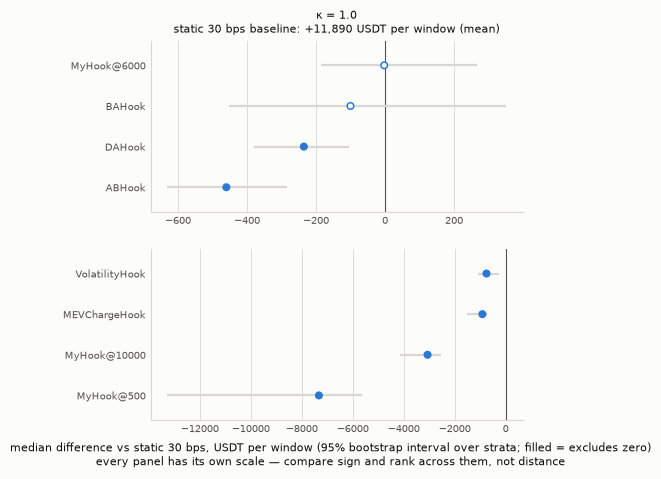

In [29]:
from IPython.display import Image, display

from experiments.figures import operating_points

effects = headline["net_result"].assign(
    configuration=LABEL.split(" — ")[0],
    subtitle=(
        f"static 30 bps baseline: "
        f"{frame.loc[frame['policy'] == BASELINE_POLICY, 'net_result'].mean():+,.0f}"
        " USDT per window (mean)"
    ),
)
for suffix in ("pdf", "png"):
    operating_points(effects, FIGURES / f"{PREFIX}effect_sizes.{suffix}")
display(Image(filename=str(FIGURES / f"{PREFIX}effect_sizes.png")))

In [30]:
# Side by side, one row per comparison. The address axis is a control that
# reproduces exactly for every policy but MEVChargeHook, so the distinct count
# is what gets quoted; Benjamini-Hochberg is invariant to exact duplication,
# so the verdicts themselves are unaffected -- only the count.
both = tests["net_result"].merge(
    tests["net_result_tt"],
    on=STRATA,
    suffixes=("", "_tt"),
)
both["agree"] = both["significant_fdr"] == both["significant_fdr_tt"]
# The same question asked of the interval, which is the verdict this notebook
# reads by. Reporting only the flag's agreement would measure the consistency of
# the instrument we are NOT using.
both["agree_ci"] = both["ci_excludes_zero"] == both["ci_excludes_zero_tt"]
both["sign_flip"] = (both["median"] * both["median_tt"]) < 0

distinct = both.drop_duplicates(
    subset=["policy", "pair", "regime", "gas_price_wei", "p"]
)
print(f"{len(both)} comparisons, {len(distinct)} distinct")
print(
    f"interval verdicts agree across valuations: {int(distinct['agree_ci'].sum())}/{len(distinct)}"
)
print(
    f"flag verdicts agree across valuations:     {int(distinct['agree'].sum())}/{len(distinct)}"
)
print(f"median changes sign across valuations:     {int(distinct['sign_flip'].sum())}")

# How often the two instruments disagree with EACH OTHER on the same comparison.
# This is the number that justifies having added the interval at all.
split = int((distinct["significant_fdr"] != distinct["ci_excludes_zero"]).sum())
print(
    f"\nflag and interval disagree on {split} of {len(distinct)} comparisons "
    f"({split / len(distinct):.1%})"
)

216 comparisons, 216 distinct
interval verdicts agree across valuations: 202/216
flag verdicts agree across valuations:     207/216
median changes sign across valuations:     10

flag and interval disagree on 8 of 216 comparisons (3.7%)


### Where the two valuations disagree

This is the table the 2026-08-09 audit made necessary. A row here is a
comparison whose verdict or whose sign depends on when the leftover inventory is
marked — which means the number in the paper has to be reported as a pair, with
the disagreement stated, not collapsed into one.


In [31]:
disagreements = distinct[~distinct["agree"] | distinct["sign_flip"]]
print(f"{len(disagreements)} disagreements of {len(distinct)} distinct comparisons")
disagreements.assign(gwei=lambda d: d["gas_price_wei"] // 10**9)[
    [
        "policy",
        "pair",
        "regime",
        "gwei",
        "median",
        "p",
        "significant_fdr",
        "median_tt",
        "p_tt",
        "significant_fdr_tt",
    ]
].round(4).head(40)

19 disagreements of 216 distinct comparisons


,policy,pair,regime,gwei,median,p,significant_fdr,median_tt,p_tt,significant_fdr_tt
163,MyHook@6000,ETH/SHIB,low,5,-217.4369,0.0249,True,-129.0249,0.1140,False
164,VolatilityHook,ETH/SHIB,high,80,-1230.9575,0.0269,True,-720.4617,0.0604,False
166,MyHook@6000,ETH/SHIB,mid,5,-270.4672,0.0315,True,-33.7136,0.6231,False
170,MyHook@6000,ETH/SHIB,high,20,938.8307,0.0564,False,1366.0539,0.0072,True
172,DAHook,ETH/SHIB,high,5,499.1688,0.0691,False,449.3386,0.0079,True
173,VolatilityHook,ETH/USDC,mid,5,-247.2733,0.0738,False,-296.9374,0.0395,True
179,VolatilityHook,ETH/USDC,high,20,-617.6231,0.1355,False,-637.5813,0.0028,True
182,VolatilityHook,ETH/SHIB,high,5,190.7200,0.1600,False,759.1326,0.0087,True
183,DAHook,ETH/USDC,low,5,-93.9116,0.1780,False,12.5652,0.8553,False
199,VolatilityHook,ETH/SHIB,high,20,-313.1004,0.5646,False,230.6309,0.9218,False


## Where a dynamic policy beats the baseline

The static levels are excluded: one of them winning means only that it moved
along its own curve. Every flag carries the median difference in USDT, the win
rate and `n_effective` beside it — "significant" answers whether an effect
exists, not whether it matters.


In [32]:
hooks = distinct[~distinct["policy"].str.startswith("MyHook@")]

# Counted by the INTERVAL, not the flag. A "significant win" of six dollars is
# not a win; an interval that clears zero at least states its own size.
for valuation, median, flag in (
    ("end-of-window", "median", "ci_excludes_zero"),
    ("trade-time", "median_tt", "ci_excludes_zero_tt"),
):
    wins = hooks[hooks[flag] & (hooks[median] > 0)]
    losses = hooks[hooks[flag] & (hooks[median] < 0)]
    print(
        f"{valuation:14s} {len(wins):3d} wins, {len(losses):3d} losses "
        f"(interval excludes zero); {len(hooks) - len(wins) - len(losses):3d} undecided"
    )

# Every policy's ledger, so a win is never read without the losses beside it,
# and with the median effect size so a count is never read as a magnitude.
ledger = pd.concat(
    [
        hooks[hooks[flag]]
        .assign(
            valuation=valuation,
            outcome=lambda d, m=median: np.where(d[m] > 0, "wins", "losses"),
        )
        .groupby(["policy", "valuation", "outcome"])
        .size()
        .rename("n")
        for valuation, median, flag in (
            ("end-of-window", "median", "ci_excludes_zero"),
            ("trade-time", "median_tt", "ci_excludes_zero_tt"),
        )
    ]
).reset_index()
ledger.pivot_table(
    index="policy", columns=["valuation", "outcome"], values="n", aggfunc="sum"
).fillna(0).astype(int)

end-of-window    3 wins, 101 losses (interval excludes zero);  31 undecided
trade-time       6 wins, 100 losses (interval excludes zero);  29 undecided


valuation      end-of-window      trade-time     
outcome               losses wins     losses wins
policy                                           
ABHook                    27    0         27    0
BAHook                    14    3         14    4
DAHook                    15    0         14    1
MEVChargeHook             24    0         23    0
VolatilityHook            21    0         22    1

### By pair — where the result actually is

Pooling the three pairs into one ledger hides the finding. The pre-registered
family is declared _per stratum_ — 3 regimes × 3 gas scenarios × 3 pairs — so
this is the level the comparison was registered at; the pooled table above is a
summary of it, not a replacement.

The two adaptive policies beat the baseline on the **volatile** pairs and lose on
the **stable** one, where there is nothing to adapt to and the adaptation only
costs. A single pooled median averages a real win against a real loss and
reports something in between that describes neither.


In [33]:
by_pair = distinct[~distinct["policy"].str.startswith("MyHook@")]

# Per pair, the median across that pair's nine strata with a bootstrap over
# them. The old version of this cell printed a median and a significance star;
# a star says nothing about how well the median is pinned down, and on this
# table three policies change verdict depending on which you read.
from experiments.stats import bootstrap_median_ci

rows = []
for (policy, pair), group in by_pair.groupby(["policy", "pair"]):
    low, high = bootstrap_median_ci(group["median"])
    rows.append(
        {
            "policy": policy,
            "pair": pair,
            "cell": f"{group['median'].median():+,.0f} [{low:+,.0f}, {high:+,.0f}]"
            + ("*" if (low > 0 or high < 0) else " "),
        }
    )
print(
    "median difference vs static 30 bps with 95% bootstrap interval, by pair\n"
    "(* = interval excludes zero)"
)
display(pd.DataFrame(rows).pivot(index="policy", columns="pair", values="cell"))

# And the win/loss split, which is what the pooled ledger flattened.
split = (
    by_pair[by_pair["ci_excludes_zero"]]
    .assign(outcome=lambda d: np.where(d["median"] > 0, "wins", "losses"))
    .pivot_table(
        index="policy", columns=["pair", "outcome"], values="p", aggfunc="count"
    )
    .fillna(0)
    .astype(int)
)
split

median difference vs static 30 bps with 95% bootstrap interval, by pair
(* = interval excludes zero)


pair,ETH/SHIB,ETH/USDC,USDC/USDT
policy,,,
ABHook,"-407 [-671, -169]*","-513 [-810, -208]*","-299 [-624, -189]*"
BAHook,"-262 [-573, +951]","+32 [-851, +415]","-542 [-924, -226]*"
DAHook,"-319 [-508, -26]*","-179 [-625, -66]*","-173 [-594, -96]*"
MEVChargeHook,"-706 [-820, +223]","-1,795 [-2,774, -1,091]*","-357 [-676, -185]*"
VolatilityHook,"-722 [-1,231, -57]*","-822 [-1,615, -247]*","-2,253 [-2,807, -1,415]*"


pair           ETH/SHIB      ETH/USDC      USDC/USDT
outcome          losses wins   losses wins    losses
policy                                              
ABHook                9    0        9    0         9
BAHook                4    2        2    1         8
DAHook                6    0        6    0         3
MEVChargeHook         6    0        9    0         9
VolatilityHook        6    0        6    0         9

## The three predictions recorded in advance

The pre-registration names three things it expects, and commits to reporting
them either way. They are checked here rather than looked for after the fact.


In [34]:
# 1. PegDefence can now activate: UU flow pushes the pool AWAY from the
#    reference, which is exactly the flow its mechanism charges. Under
#    arbitrage-only flow it was a de-facto static 1 bps (0 of 1805 trades were
#    moving away). If it still never fires, that is a mechanism failure and a
#    finding, not a data artifact. The fee itself lives in the traces
#    (notebook 08); here we ask whether its result stopped being worst-in-class.
# Ranked best first, and the position is spelled out as a place from the top,
# because "rank 1 of 12" off an ascending sort reads as the winner when it is
# the opposite.
ranking = (
    frame.groupby("policy")[["net_result", "net_result_tt", "uu_fee_share"]]
    .mean()
    .sort_values("net_result", ascending=False)
)
if "PegDefence" in ranking.index:
    place = list(ranking.index).index("PegDefence") + 1
    print(
        f"PegDefence: {place} of {len(ranking)} by mean net_result "
        f"({'best' if place == 1 else 'worst' if place == len(ranking) else 'mid'}), "
        f"{ranking.loc['PegDefence', 'net_result']:+,.0f} end / "
        f"{ranking.loc['PegDefence', 'net_result_tt']:+,.0f} trade-time"
    )
else:
    print(
        "PegDefence: not in this run -- dropped from the paper before the "
        "2026-08-12 gas-fix rerun. Its pre-fix result (worst in class at "
        "both operating points) is in the archived matrix; this prediction "
        "check is vacuous here."
    )


def verdict(policy: str) -> str:
    """Effect size, interval, and the flag -- in that order of prominence."""
    row = summary.loc[policy]
    tail = "excludes zero" if row["ci_excludes_zero"] else "COVERS ZERO"
    flagged = int(distinct[distinct["policy"] == policy]["significant_fdr"].sum())
    total = len(distinct[distinct["policy"] == policy])
    return (
        f"{row['median']:+,.0f} [{row['ci_low']:+,.0f}, {row['ci_high']:+,.0f}] "
        f"USDT/window, interval {tail}; significant in {flagged}/{total} strata"
    )


# 2. The ABHook litmus. Retail volume now responds to the fee of its own
#    direction, so a constant sum reallocated across directions has a mechanism
#    to retain more benign flow. Direction of the effect was NOT asserted.
print(f"\nABHook:             {verdict('ABHook')}")

# 3. MEVChargeHookFixed is expected to stay indistinguishable from static
#    30 bps: once the impact measure is dimensionless its trigger sits far
#    above anything retail or arbitrage does against a 20M basket.
# This is the case the interval was added for. Read by the flag it is a
# consistent finding; read by its size it is a rounding error on a baseline of
# thousands, and the two readings support opposite sentences.
baseline_scale = frame.loc[frame["policy"] == BASELINE_POLICY, "net_result"].mean()
if "MEVChargeHookFixed" not in summary.index:
    print(
        "MEVChargeHookFixed: not in this run -- dropped from the paper "
        "(collapses to a constant 30 bps in practice); prediction check "
        "vacuous here."
    )
else:
    print(f"MEVChargeHookFixed: {verdict('MEVChargeHookFixed')}")
# Only as a fraction of a baseline that is making money. At the informed
# operating point the baseline mean is NEGATIVE, and this ratio then reports a
# 52 USDT LOSS as "+10.7% of the baseline" -- the sign flips because the
# denominator is negative, not because anything improved. Same trap the second
# pre-registration's prediction fell into; refuse to print it rather than
# leaving a reader to notice.
if "MEVChargeHookFixed" in summary.index and baseline_scale > 0:
    print(
        f"{'':20s}= {summary.loc['MEVChargeHookFixed', 'median'] / baseline_scale:+.3%} "
        "of the baseline result"
    )
else:
    print(
        f"{'':20s}  (not expressed as a % of the baseline: the baseline mean is "
        f"{baseline_scale:+,.0f}, and a ratio to a negative denominator flips sign)"
    )

ranking.round(2)

PegDefence: not in this run -- dropped from the paper before the 2026-08-12 gas-fix rerun. Its pre-fix result (worst in class at both operating points) is in the archived matrix; this prediction check is vacuous here.

ABHook:             -460 [-630, -284] USDT/window, interval excludes zero; significant in 27/27 strata
MEVChargeHookFixed: not in this run -- dropped from the paper (collapses to a constant 30 bps in practice); prediction check vacuous here.
                      (not expressed as a % of the baseline: the baseline mean is +11,890, and a ratio to a negative denominator flips sign)


,net_result,net_result_tt,uu_fee_share
policy,,,
MyHook@6000,11932.29,12577.80,0.96
MyHook@3000,11890.14,12508.53,0.89
BAHook,11820.15,12463.14,0.92
DAHook,11709.33,12327.58,0.89
ABHook,11348.67,11969.67,0.89
MEVChargeHook,10991.62,11631.03,0.93
VolatilityHook,10667.77,11315.95,0.90
MyHook@10000,7936.14,8614.32,0.98
MyHook@500,1643.91,2195.46,0.73


**MEVChargeHook rows are not comparable to the first two experiments.** Its
`feeMax` was clamped 1000 → 100 bps and `flaggedFeeAdditional` 400 → 40 bps for
this matrix, because the 2026-08-09 audit found it charging above the shared fee
box on 49% of its arb-only swaps. That is a configuration change declared in the
pre-registration, and it changes the policy's effective behaviour.

## Figures

Both valuations are drawn unconditionally. `draw_all_uu` exists so that one call
produces the whole set — a figure reachable only from a notebook cell someone
forgot to run is a figure that goes stale unnoticed, and one already did.

It raises if `TRACES` holds no swap traces, because the fee figure can only be
drawn from the JSONL event logs and an empty one would read as "no policy ever
moved its fee".


In [35]:
written = draw_all_uu(frame, TRACES, FIGURES, prefix=PREFIX, note=LABEL)
# The list this call returned, not a glob: `uu_*` also matches `uu_t01_*`,
# so globbing made the headline run claim the other configuration's figures.
print("\n".join(sorted(p.name for p in written)))


uu_fee_distribution.pdf
uu_flow.pdf
uu_frontier.pdf
uu_frontier_tt.pdf
uu_gas_breakeven.pdf
uu_net_result_by_regime.pdf
uu_net_result_by_regime_tt.pdf
uu_valuation_comparison.pdf


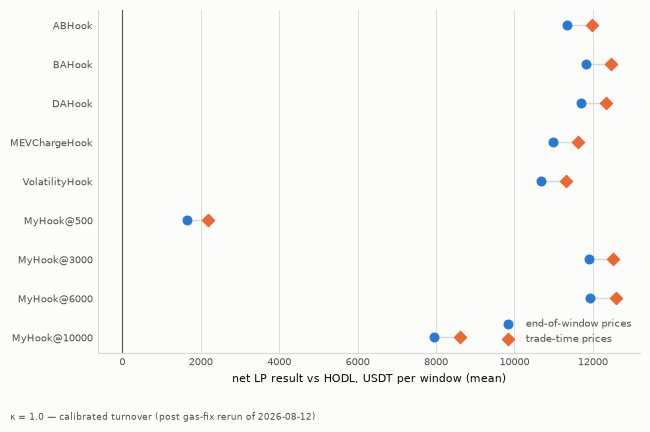

In [36]:
from IPython.display import Image, display

from experiments.figures import (
    figure_note,
    frontier,
    net_result_by_regime,
    uu_flow,
    valuation_comparison,
)


def show(function, frame, *extra, name):
    """PNG for the notebook; the PDF beside it is what the paper uses.

    Every figure takes (frame, out, ...), so the path goes second and anything
    else -- the valuation, here -- follows it. `name` is the stem WITHOUT the
    operating-point prefix, which is added here so no call site can forget it
    and write one configuration's PNG over the other's.
    """
    out = FIGURES / f"{PREFIX}{name}.png"
    with figure_note(LABEL):
        function(frame, out, *extra)
    display(Image(filename=str(out)))


show(valuation_comparison, frame, name="valuation_comparison")


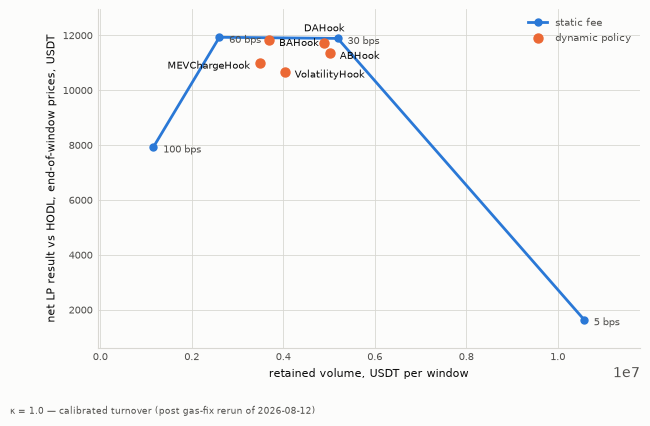

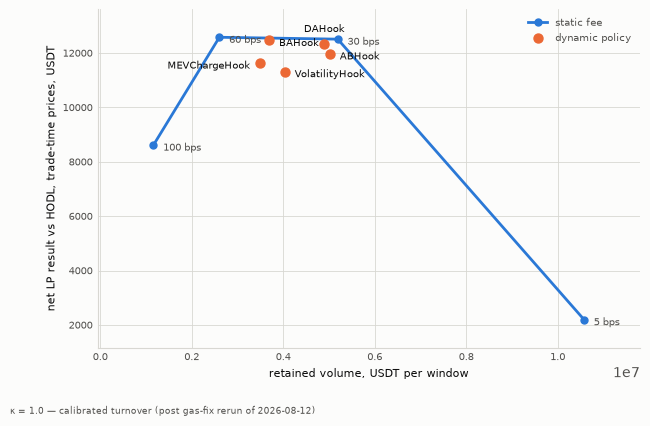

In [37]:
# The frontier under each valuation. A policy wins by sitting above the static
# curve at the same retained volume -- the reading that excludes "charge the
# maximum so nobody trades". Two panels because the curve itself moves.
show(frontier, frame, "net_result", name="frontier")
show(frontier, frame, "net_result_tt", name="frontier_tt")


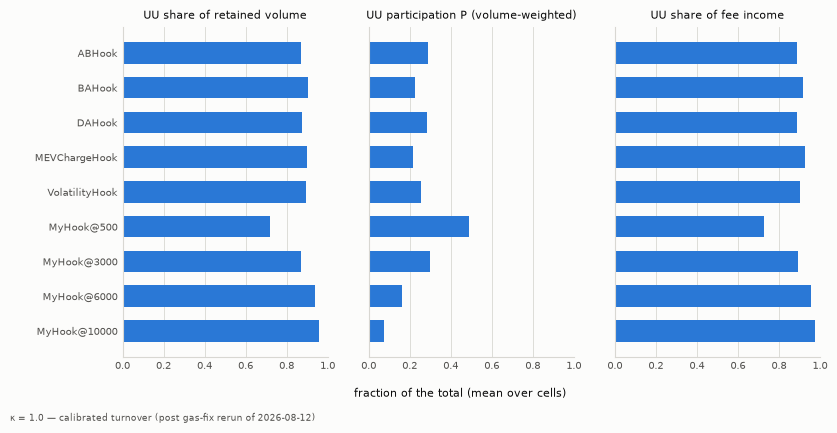

In [38]:
show(uu_flow, frame, name="flow")


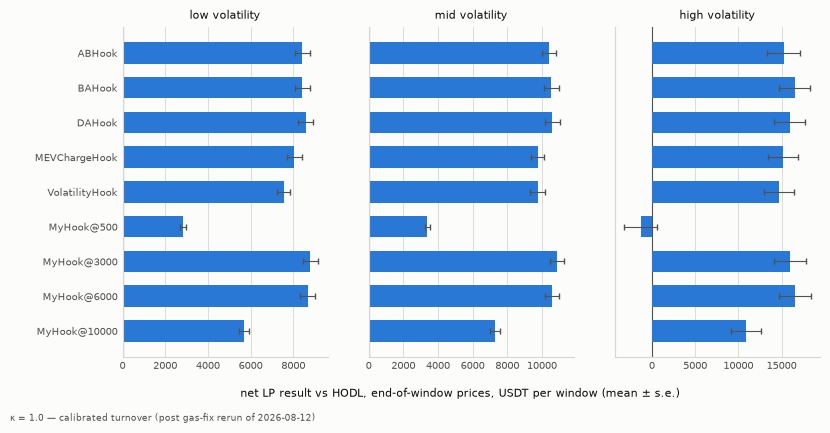

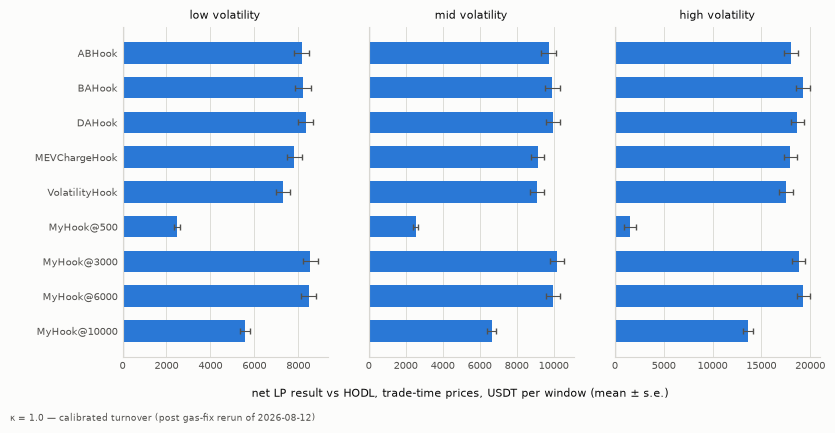

In [39]:
show(net_result_by_regime, frame, "net_result", name="net_result_by_regime")
show(net_result_by_regime, frame, "net_result_tt", name="net_result_by_regime_tt")


## The address mode was a control, and should behave like one

`persistent` vs `fresh` changes only who sends the arbitrage swap — UU swaps
always come from fresh addresses, a continuum of users, so the axis does not
touch them. Identical results for every policy but `MEVChargeHook`, the one
policy that reads the sender, is evidence the harness is not leaking state
between cells.


In [40]:
modes = frame.pivot_table(
    index="policy", columns="address_mode", values="net_result", aggfunc="median"
)
if modes.shape[1] < 2:
    # The axis was dropped on 2026-08-10, before this matrix ran. Under UU flow
    # it carried nothing: across all 7,776 paired cells of the superseded run,
    # `fresh` and `persistent` agreed to the LAST BIT for every one of the
    # twelve policies -- including MEVChargeHook, the only one that reads the
    # sender, because UU swaps always come from fresh addresses and the
    # arbitrageur it could have profiled barely traded. Half the matrix was
    # producing rows the analysis then deduplicated away.
    #
    # The risk is stated rather than dismissed: at a configuration where the
    # arbitrageur trades more, MEVChargeHook could begin to distinguish the
    # modes, and this run cannot detect that.
    print(
        f"address mode is not an axis in this run: {list(modes.columns)}.\n"
        "See 2026-08-10-r-correction-preregistration.md for why, and for the "
        "limitation it leaves behind."
    )
modes.round(2)

address mode is not an axis in this run: ['persistent'].
See 2026-08-10-r-correction-preregistration.md for why, and for the limitation it leaves behind.


address_mode,persistent
policy,
ABHook,10469.44
BAHook,10573.59
DAHook,10783.97
MEVChargeHook,10008.98
MyHook@10000,7298.96
MyHook@3000,11040.96
MyHook@500,3311.78
MyHook@6000,10767.89
VolatilityHook,9551.13
